In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from bs4 import BeautifulSoup
import requests
import re 

**Импорт датафрейма фильмов**

In [192]:
movies_table = pd.read_csv('../data/Dataset1.csv', sep=",", encoding="utf-8")

In [193]:
pd.options.display.max_columns = None
movies_table.head(10)

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,actor_2_name,Actor_1_Facebook_likes,gross,genres,actor_1_name,movie_Title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes;
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,Avatar,886204.0,4834.0,Wes Studi,0.0,avatar|future|marine|native|paraplegic,http://www.imdb.com/title/tt0499549/?ref_=fn_t...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000;
1,Colour,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,Johnny Depp,Pirates of the Caribbean: At World's End,471220.0,48350.0,Jack Davenport,0.0,goddess|marriage ceremony|marriage proposal|pi...,http://www.imdb.com/title/tt0449088/?ref_=fn_t...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0;
2,Colour,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,Christoph Waltz,Spectre,275868.0,11700.0,Stephanie Sigman,1.0,bomb|espionage|sequel|spy|terrorist,http://www.imdb.com/title/tt2379713/?ref_=fn_t...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000;
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,Tom Hardy,The Dark Knight Rises,1144337.0,106759.0,Joseph Gordon-Levitt,0.0,deception|imprisonment|lawlessness|police offi...,http://www.imdb.com/title/tt1345836/?ref_=fn_t...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000;
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,Doug Walker,Star Wars: Episode VII - The Force Awakens ...,8.0,143.0,NaN,0.0,NaN,http://www.imdb.com/title/tt5289954/?ref_=fn_t...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0;
5,Colour,Andrew Stanton,462.0,132.0,475.0,530.0,Samantha Morton,640.0,73058679.0,Action|Adventure|Sci-Fi,Daryl Sabara,John Carter,212204.0,1873.0,Polly Walker,1.0,alien|american civil war|male nipple|mars|prin...,http://www.imdb.com/title/tt0401729/?ref_=fn_t...,738.0,English,USA,PG-13,263700000.0,2012.0,632.0,6.6,2.35,24000;
6,Color,Sam Raimi,392.0,156.0,0.0,4000.0,James Franco,24000.0,336530303.0,Action|Adventure|Romance,J.K. Simmons,Spider-Man 3,383056.0,46055.0,Kirsten Dunst,0.0,sandman|spider man|symbiote|venom|villain,http://www.imdb.com/title/tt0413300/?ref_=fn_t...,1902.0,English,USA,PG-13,258000000.0,2007.0,11000.0,6.2,2.35,0;
7,Color,Nathan Greno,324.0,100.0,15.0,284.0,Donna Murphy,799.0,200807262.0,Adventure|Animation|Comedy|Family|Fantasy|Musi...,Brad Garrett,Tangled,294810.0,2036.0,M.C. Gainey,1.0,17th century|based on fairy tale|disney|flower...,http://www.imdb.com/title/tt0398286/?ref_=fn_t...,387.0,English,USA,PG,260000000.0,2010.0,553.0,7.8,1.85,29000;
8,Colour,Joss Whedon,635.0,141.0,0.0,19000.0,Robert Downey Jr.,26000.0,458991599.0,Action|Adventure|Sci-Fi,Chris Hemsworth,Avengers: Age of Ultron,462669.0,92000.0,Scarlett Johansson,4.0,artificial intelligence|based on comic book|ca...,http://www.imdb.com/title/tt2395427/?ref_=fn_t...,1117.0,English,USA,PG-13,250000000.0,2015.0,21000.0,7.5,2.35,118000;
9,Colour,David Yates,375.0,153.0,282.0,10000.0,Daniel Radcliffe,25000.0,301956980.0,Adventure|Family|Fantasy|Mystery,Alan Rickman,Harry Potter and the Half-Blood Prince,321795.0,58753.0,Rupert Grint,3.0,blood|book|love|potion|professor,http://www.imdb.com/title/tt0417741/?ref_=fn_t...,973.0,English,UK,PG,250000000.0,2009.0,11000.0,7.5,2.35,10000;


In [194]:
movies_table.describe()

,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,Actor_1_Facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio
count,4927.000000,4959.000000,4872.000000,4953.000000,4968.000000,4.104000e+03,4.974000e+03,4974.000000,4961.000000,4956.000000,4.494000e+03,4869.000000,4963.000000,4974.000000,4654.000000
mean,140.572965,107.193991,691.233990,647.790430,6573.525765,4.862765e+07,8.382561e+04,9729.287495,1.372707,273.584746,3.998652e+07,2002.487985,1660.086641,6.439767,2.223350
std,121.858265,24.977939,2822.022077,1672.724849,15077.147622,6.853339e+07,1.386775e+05,18228.145064,2.017257,378.750005,2.073754e+08,12.433410,4055.957071,1.124002,1.393249
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000
25%,50.000000,93.000000,7.000000,135.000000,617.000000,5.480826e+06,8.688250e+03,1430.250000,0.000000,65.000000,6.000000e+06,1999.000000,284.000000,5.800000,1.850000
50%,110.000000,103.000000,49.000000,372.000000,989.000000,2.559138e+07,3.450400e+04,3097.500000,1.000000,157.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000
75%,195.000000,118.000000,197.000000,636.000000,11000.000000,6.241428e+07,9.646275e+04,13808.750000,2.000000,327.000000,4.500000e+07,2011.000000,919.000000,7.200000,2.350000
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000


In [195]:
(movies_table.isna().sum()/movies_table.shape[0]*100).sort_values(ascending=False)

gross                         18.619869
budget                        10.886377
aspect_ratio                   7.713663
content_rating                 7.257585
plot_keywords                  4.283165
title_year                     3.450327
director_Facebook_likes        3.390839
Director_Name                  3.390839
num_Critic_for_reviews         2.300218
actor_3_Facebook_likes         1.784652
actor_3_name                   1.784652
num_user_for_reviews           1.725164
duration                       1.665675
facenumber_in_poster           1.626016
language                       1.626016
actor_2_facebook_likes         1.586357
actor_2_name                   1.586357
Actor_1_Facebook_likes         1.487210
actor_1_name                   1.487210
country                        1.427722
movie_imdb_link                1.368233
movie_Title                    1.368233
genres                         1.368233
 cast_total_facebook_likes     1.368233
imdb_score                     1.368233


**Важные данные можно спарсить с сайта imdb, так как на него есть ссылка почти в каждом элементе**

In [196]:
def fast_parse(url):
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
        'Accept-Language': 'en-US,en;q=0.9'
    }
    
    try:
        response = requests.get(url, headers=headers)
        response.raise_for_status()
        
        soup = BeautifulSoup(response.content, 'html.parser')
        
        movie_data = {
            'Director_Name': None,
            'gross': None,
            'genres': None,
            'country': None,
            'content_rating': None,
            'budget': None,
            'title_year': None,
            'imdb_score': None,
        }
            
        director_element = soup.find('a', {
            'class': 'ipc-metadata-list-item__list-content-item ipc-metadata-list-item__list-content-item--link',
            'href': re.compile(r'/name/nm\d+/')
        })
        if director_element:
            movie_data['Director_Name'] = director_element.text.strip()
        
        rating_element = soup.find('span', {'class': 'sc-bde20123-1 cMEQkK'})
        if rating_element:
            movie_data['imdb_score'] = float(rating_element.text.strip())
        
        year_element = soup.find('a', {'class': 'ipc-link ipc-link--baseAlt ipc-link--inherit-color'}, href=re.compile(r'releaseinfo'))
        if year_element:
            year_text = year_element.text.strip()
            if year_text.isdigit():
                movie_data['title_year'] = int(year_text)
        
        genres_section = soup.find_all('a', {'class': 'ipc-chip ipc-chip--on-baseAlt'})
        if genres_section:
            genres = [genre.text.strip() for genre in genres_section]
            movie_data['genres'] = '|'.join(genres)
        
        budget_section = soup.find('li', {'data-testid': 'title-boxoffice-budget'})
        if budget_section:
            budget_text = budget_section.find('span', {'class': 'ipc-metadata-list-item__list-content-item'})
            if budget_text:
                movie_data['budget'] = int(''.join(filter(str.isdigit, budget_text.text.strip())))
        
        gross_section = soup.find('li', {'data-testid': 'title-boxoffice-cumulativeworldwidegross'})
        if gross_section:
            gross_text = gross_section.find('span', {'class': 'ipc-metadata-list-item__list-content-item'})
            if gross_text:
                movie_data['gross'] = int(gross_text.text.strip().replace('$', '').replace(',', ''))
        
        country_section = soup.find('li', {'data-testid': 'title-details-origin'})
        if country_section:
            country_text = country_section.find('a', {'class': 'ipc-metadata-list-item__list-content-item ipc-metadata-list-item__list-content-item--link'})
            if country_text:
                movie_data['country'] = country_text.text.strip()
        
        content_rating_section = soup.find('a', {'class': 'ipc-link ipc-link--baseAlt ipc-link--inherit-color'}, href=re.compile(r'parentalguide'))
        if content_rating_section:
            movie_data['content_rating'] = content_rating_section.text.strip()

        rating_element = soup.find('span', class_='sc-4dc495c1-1 lbQcRY')
        movie_data['imdb_score'] = float(rating_element.text.strip())

        votes_element = soup.find('div', class_='sc-4dc495c1-3 eNfgcR').text.strip()
        votes_num = 0    
        if 'M' in votes_element:
            votes_num = int(float(votes_element.replace('M', '')) * 1_000_000)
        elif 'K' in votes_element:
            votes_num = int(float(votes_element.replace('K', '')) * 1_000)
        else:
            votes_num = int(votes_element.replace(',', ''))

        movie_data['num_voted_users'] = votes_num#votes_element.text.strip()
        
        return movie_data
        
    except requests.exceptions.RequestException as e:
        print(f"Ошибка при запросе к {url}: {e}")
        return None
    except Exception as e:
        print(f"Ошибка при парсинге {url}: {e}")
        return None

In [197]:
fast_parse('http://www.imdb.com/title/tt0499549/?ref_=fn_tt_tt_1,3054,English,USA,PG-13,237000000,2009,936,7.9,1.78,33000')

{'Director_Name': 'James Cameron',
 'gross': 2923710708,
 'genres': 'Action Epic|Adventure Epic|Epic|Fantasy Epic|Sci-Fi Epic|Action|Adventure|Fantasy|Sci-Fi',
 'country': 'United States',
 'content_rating': 'PG-13',
 'budget': 237000000,
 'title_year': 2009,
 'imdb_score': 7.9,
 'num_voted_users': 1500000}

In [198]:
from concurrent.futures import ThreadPoolExecutor

def fill_missing_data(df, nan_columns):
    df_filled = df.copy()
    
    for index, row in df_filled.iterrows():
        if index % 100 == 0:
            print(index)
        if row[nan_columns].isna().any():
            url = row['movie_imdb_link']
            if pd.notna(url):
                movie_data = fast_parse(url)
                for col in nan_columns:
                    if pd.isna(row[col]) and movie_data.get(col) is not None:
                        df_filled.at[index, col] = movie_data[col]
    return df_filled

In [199]:
import os

if os.path.isfile('../data/FilledMovies.csv'):
    movies_table = pd.read_csv('../data/FilledMovies.csv', sep = ',', encoding='utf-8')
else:
    nan_columns = ['Director_Name', 'gross', 'genres', 'country', 'content_rating', 'budget', 'title_year', 'imdb_score']
    movies_table = fill_missing_data(movies_table, nan_columns)
    movies_table.to_csv('../data/FilledMovies.csv', index=False)

In [200]:
(movies_table.isna().sum()/movies_table.shape[0]*100).sort_values(ascending=False)

gross                         9.716439
budget                        8.605988
aspect_ratio                  7.713663
plot_keywords                 4.283165
director_Facebook_likes       3.390839
title_year                    3.152885
content_rating                2.795955
num_Critic_for_reviews        2.300218
actor_3_name                  1.784652
actor_3_Facebook_likes        1.784652
num_user_for_reviews          1.725164
duration                      1.665675
language                      1.626016
facenumber_in_poster          1.626016
actor_2_name                  1.586357
actor_2_facebook_likes        1.586357
actor_1_name                  1.487210
Actor_1_Facebook_likes        1.487210
country                       1.388063
genres                        1.368233
movie_imdb_link               1.368233
movie_Title                   1.368233
Director_Name                 1.368233
 cast_total_facebook_likes    1.368233
imdb_score                    1.368233
num_voted_users          

**Все данные, которые не получилось спарсить и невозможно заполнить автоматически, стоит удалить**

In [201]:
movies_table = movies_table.dropna(subset=['gross'])
movies_table = movies_table.dropna(subset=['budget'])

In [202]:
(movies_table.isna().sum()/movies_table.shape[0]*100).sort_values(ascending=False)

aspect_ratio                  3.182657
plot_keywords                 1.452952
content_rating                0.599631
actor_3_Facebook_likes        0.253690
actor_3_name                  0.253690
facenumber_in_poster          0.230627
language                      0.161439
num_Critic_for_reviews        0.161439
actor_2_name                  0.115314
actor_2_facebook_likes        0.115314
color                         0.115314
Actor_1_Facebook_likes        0.069188
actor_1_name                  0.069188
num_user_for_reviews          0.069188
duration                      0.046125
movie_Title                   0.000000
Director_Name                 0.000000
genres                        0.000000
gross                         0.000000
director_Facebook_likes       0.000000
movie_imdb_link               0.000000
num_voted_users               0.000000
 cast_total_facebook_likes    0.000000
country                       0.000000
title_year                    0.000000
budget                   

**Логично заполнить все пропуски в колонках facebook_likes медианой среди фильмов вышедших в тот же год**

In [203]:
facebook_columns = ['actor_3_Facebook_likes', 'actor_2_facebook_likes', 'Actor_1_Facebook_likes']

for col in facebook_columns:
    movies_table[col] = movies_table.groupby('title_year')[col].transform(lambda x: x.fillna(x.median()))

**Аналогичные действия стоит произвести с параметрами aspect_ratio, language, color, content_rating**

In [204]:
movies_table['aspect_ratio'] = movies_table.groupby('title_year')['aspect_ratio'].transform(lambda x: x.fillna(x.median()))

In [205]:
movies_table['language'] = movies_table.groupby('country')['language'].transform(lambda x: x.fillna(x.mode()[0]))

In [206]:
movies_table['color'] = movies_table.groupby('title_year')['color'].transform(lambda x: x.fillna(x.mode()[0]))

In [207]:
movies_table['content_rating'] = movies_table.groupby(
    movies_table['genres'].str.split('|').str[0]
)['content_rating'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else None)
)

In [208]:
movies_table['num_user_for_reviews'] = movies_table['num_user_for_reviews'].fillna(movies_table['num_user_for_reviews'].median())

**Так как имена актеров неизвестны, пока стоит заполнить пропуски словом Unnamed**

In [209]:
actors_columns = ['actor_3_name', 'actor_2_name', 'actor_1_name']

for col in actors_columns:
    movies_table[col] = movies_table[col].fillna('Unnamed')

In [210]:
columns = ['facenumber_in_poster', 'duration', 'num_Critic_for_reviews']

for col in columns:
    movies_table[col] = movies_table[col].fillna(movies_table[col].median())

**Столбец ключевых можно заполнить названием фильма**

In [211]:
mask = movies_table['plot_keywords'].isna()
movies_table.loc[mask, 'plot_keywords'] = movies_table.loc[mask, 'movie_Title'].str.lower()

In [212]:
(movies_table.isna().sum()/movies_table.shape[0]*100).sort_values(ascending=False)

color                         0.0
Director_Name                 0.0
num_Critic_for_reviews        0.0
duration                      0.0
director_Facebook_likes       0.0
actor_3_Facebook_likes        0.0
actor_2_name                  0.0
Actor_1_Facebook_likes        0.0
gross                         0.0
genres                        0.0
actor_1_name                  0.0
movie_Title                   0.0
num_voted_users               0.0
 cast_total_facebook_likes    0.0
actor_3_name                  0.0
facenumber_in_poster          0.0
plot_keywords                 0.0
movie_imdb_link               0.0
num_user_for_reviews          0.0
language                      0.0
country                       0.0
content_rating                0.0
budget                        0.0
title_year                    0.0
actor_2_facebook_likes        0.0
imdb_score                    0.0
aspect_ratio                  0.0
movie_facebook_likes;         0.0
dtype: float64

**Все элементы заполнены, учтем инфляцию**

In [213]:
# url = "http://www.usinflationcalculator.com/inflation/consumer-price-index-and-annual-percent-changes-from-1913-to-2008/"

# r = requests.get(url, verify=False)
#data = r.text
with open('../data/site.txt', 'r', encoding='utf-8') as file:
    data = file.read()
soup = BeautifulSoup(data, 'html.parser')

table = soup.find('table')
rows = table.tbody.findAll('tr')

years = []
cpis = []

for row in rows:
    year = row.findAll('td')[0].get_text()
    if year.isdigit() and int(year) < 2017:
        years.append(int(year))
        cpis.append(float(row.findAll('td')[13].get_text()))

cpi_table = pd.DataFrame({
    "year": years,
    "avg_annual_cpi": cpis
})

cpi_table.head(20)

cpi_table.to_csv('../data/Practice2_Sakhan_CPI.csv', index=False)

C:\Users\admin\AppData\Local\Temp\ipykernel_6120\2835160203.py:10: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  rows = table.tbody.findAll('tr')
C:\Users\admin\AppData\Local\Temp\ipykernel_6120\2835160203.py:16: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  year = row.findAll('td')[0].get_text()
C:\Users\admin\AppData\Local\Temp\ipykernel_6120\2835160203.py:19: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  cpis.append(float(row.findAll('td')[13].get_text()))


In [214]:
def get_real_value(nominal_amt, old_cpi, new_cpi):
    real_value = (nominal_amt * new_cpi) / old_cpi
    return real_value

In [215]:
CPI_2016 = cpi_table[cpi_table['year'] == 2016]['avg_annual_cpi'].iloc[0]
CPI_2016

np.float64(240.007)

In [216]:
cpi_table.isna().sum()

year              0
avg_annual_cpi    0
dtype: int64

In [217]:

real_domestic_gross = []
real_budget_values = []

for index, row in movies_table.iterrows():
    gross = row['gross']
    budget = row['budget']
    year = row['title_year']
    
    cpi = float(cpi_table[cpi_table['year'] == int(year)]['avg_annual_cpi'].iloc[0])

    real_gross = get_real_value(gross, cpi, CPI_2016)
    real_budget = get_real_value(budget, cpi, CPI_2016)
    real_domestic_gross.append(real_gross)
    real_budget_values.append(real_budget)

movies_table["real_domestic_gross"] = real_domestic_gross
movies_table["real_budget"] = real_budget_values

In [218]:
profits = []
roi_vals = []

for index, row in movies_table.iterrows():
    profit = row['real_domestic_gross'] - row['real_budget']
    budget = row['real_budget']
    num = profit - budget
    den = budget
    roi = (num / den) * 100
    
    profits.append(profit)
    roi_vals.append(roi)

movies_table['profit'] = profits
movies_table['roi'] = roi_vals

In [219]:
movies_table.head(5)

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,actor_2_name,Actor_1_Facebook_likes,gross,genres,actor_1_name,movie_Title,num_voted_users,cast_total_facebook_likes,actor_3_name,facenumber_in_poster,plot_keywords,movie_imdb_link,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes;,real_domestic_gross,real_budget,profit,roi
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,Avatar,886204.0,4834.0,Wes Studi,0.0,avatar|future|marine|native|paraplegic,http://www.imdb.com/title/tt0499549/?ref_=fn_t...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000;,8.507937e+08,2.651368e+08,5.856569e+08,120.888543
1,Colour,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,Johnny Depp,Pirates of the Caribbean: At World's End,471220.0,48350.0,Jack Davenport,0.0,goddess|marriage ceremony|marriage proposal|pi...,http://www.imdb.com/title/tt0449088/?ref_=fn_t...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0;,3.582208e+08,3.473329e+08,1.088790e+07,-96.865283
2,Colour,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,Christoph Waltz,Spectre,275868.0,11700.0,Stephanie Sigman,1.0,bomb|espionage|sequel|spy|terrorist,http://www.imdb.com/title/tt2379713/?ref_=fn_t...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000;,2.025981e+08,2.480907e+08,-4.549257e+07,-118.337071
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,Tom Hardy,The Dark Knight Rises,1144337.0,106759.0,Joseph Gordon-Levitt,0.0,deception|imprisonment|lawlessness|police offi...,http://www.imdb.com/title/tt1345836/?ref_=fn_t...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000;,4.684551e+08,2.613385e+08,2.071167e+08,-20.747743
5,Colour,Andrew Stanton,462.0,132.0,475.0,530.0,Samantha Morton,640.0,73058679.0,Action|Adventure|Sci-Fi,Daryl Sabara,John Carter,212204.0,1873.0,Polly Walker,1.0,alien|american civil war|male nipple|mars|prin...,http://www.imdb.com/title/tt0401729/?ref_=fn_t...,738.0,English,USA,PG-13,263700000.0,2012.0,632.0,6.6,2.35,24000;,7.637218e+07,2.756598e+08,-1.992877e+08,-172.294775


**Очистим данные от выбросов**

In [220]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

movies_table = movies_table.copy()

for col in ['budget', 'gross', 'imdb_score', 'num_voted_users', 
            'actor_facebook_likes', 'duration', 'title_year']:
    if col in movies_table.columns:
        movies_table = remove_outliers(movies_table, col)

# Визуальный анализ

<Axes: >

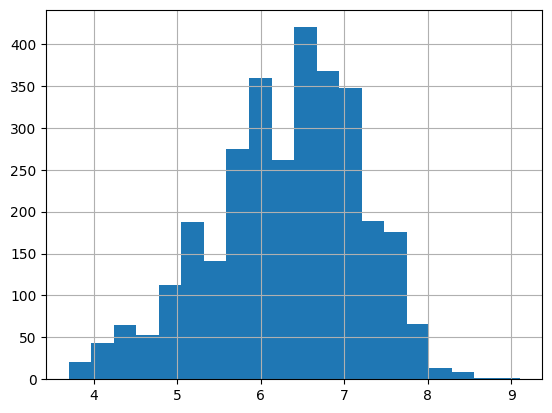

In [221]:
movies_table['imdb_score'].hist(bins=20)

<Axes: xlabel='budget', ylabel='gross'>

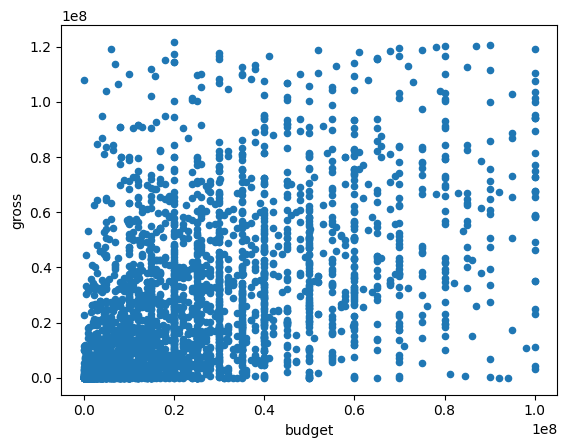

In [222]:
movies_table.plot.scatter('budget', 'gross')

<Axes: xlabel='genres'>

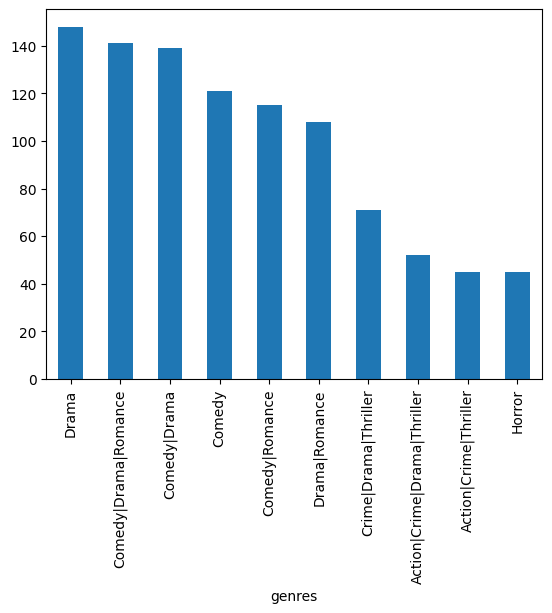

In [239]:
movies_table['genres'].value_counts().head(10).plot.bar()


<Axes: xlabel='num_voted_users', ylabel='imdb_score'>

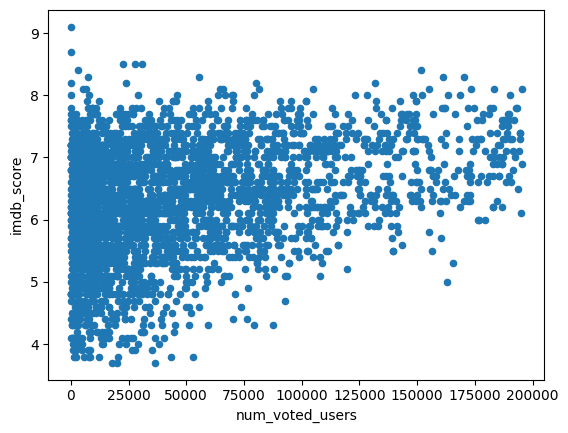

In [224]:
movies_table.plot.scatter('num_voted_users', 'imdb_score')

<Axes: xlabel='Actor_1_Facebook_likes', ylabel='imdb_score'>

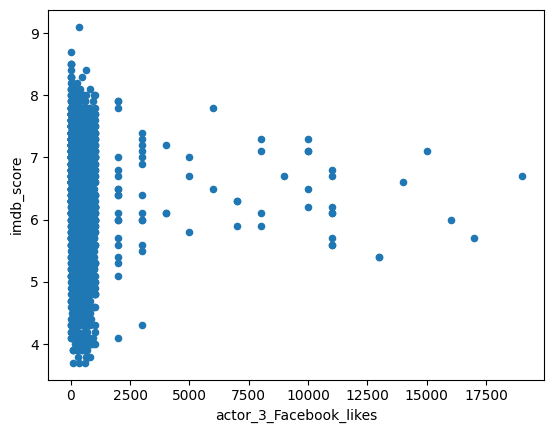

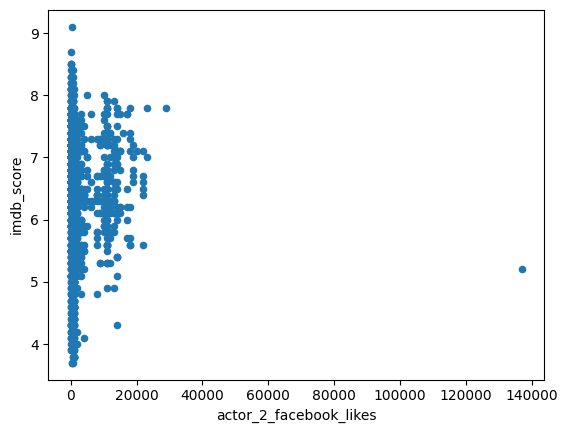

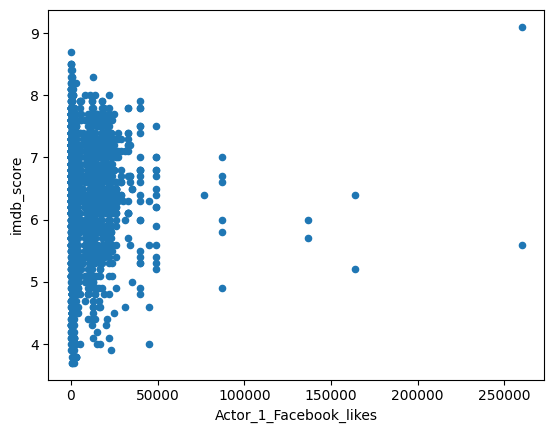

In [236]:
movies_table.plot.scatter('actor_3_Facebook_likes', 'imdb_score')
movies_table.plot.scatter('actor_2_facebook_likes', 'imdb_score')
movies_table.plot.scatter('Actor_1_Facebook_likes', 'imdb_score')

**Успех фильма не зависит от лайков в фейсбуке**

<Axes: xlabel='title_year'>

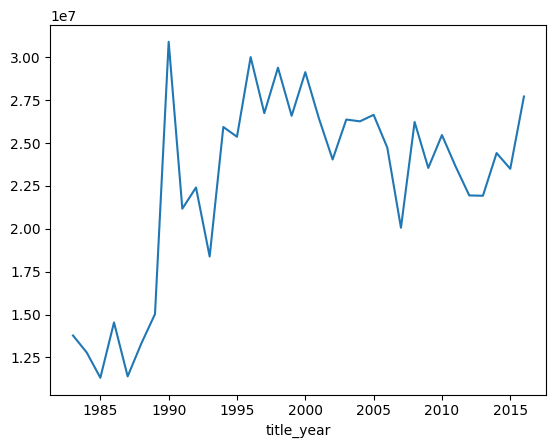

In [226]:
movies_table.groupby('title_year')['budget'].mean().plot()

**Бюджет увеличивался до 90-х годов, а после пошло более-менее равномерное распределение**

<Axes: xlabel='country'>

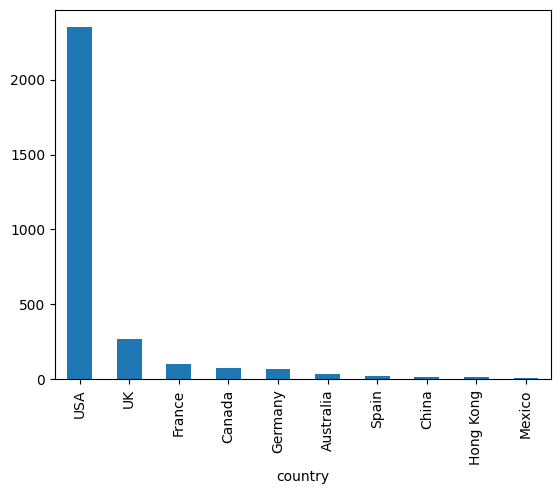

In [227]:
movies_table['country'].value_counts().head(10).plot.bar()

**Большинство фильмов снято в США**

<Axes: >

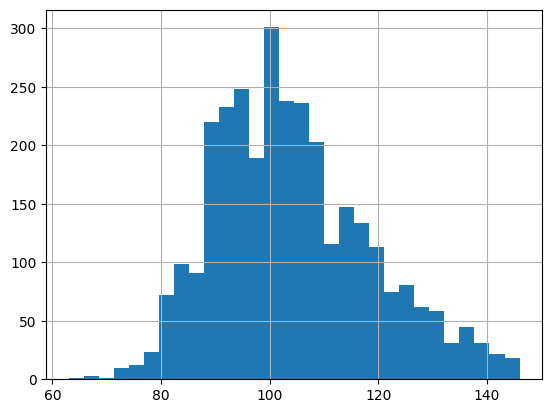

In [228]:
movies_table['duration'].hist(bins=30)

**Большинство фильмов длится 100 минут**

<Axes: title={'center': 'gross'}, xlabel='content_rating'>

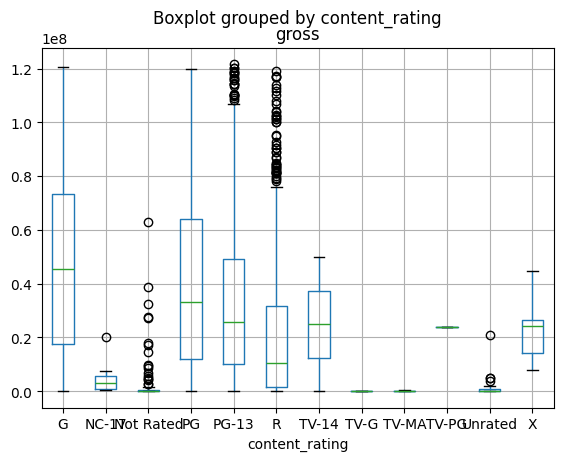

In [229]:
movies_table.boxplot(column='gross', by='content_rating')

**Самые доходные фильмы - фильмы с меньшим возрастным рейтингом**

In [231]:
movies_table['Director_Name'].value_counts().head(1)

Director_Name
Woody Allen    16
Name: count, dtype: int64

**Woody Allen снял большее количество фильмов**